In [1]:
!pip uninstall -y tabpfn tabpfn-extensions tabpfn-common-utils
!pip install tabpfn==6.4.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 621.6/621.6 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.3/228.3 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 8.2 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [2]:
import joblib
import numpy as np
import pandas as pd
import shap

from sklearn.model_selection import train_test_split

tabpfn_model = joblib.load("/content/tabpfn_model_EMG.pkl")
svm_model = joblib.load("/content/svm_model_EMG.pkl")
rf_model = joblib.load("/content/rf_model_EMG.pkl")

svm_scaler = joblib.load("/content/svm_scaler_EMG.pkl")

tab_features = joblib.load("/content/tabpfn_selected_features_EMG.pkl")
svm_features = joblib.load("/content/svm_selected_features_EMG.pkl")
rf_features = joblib.load("/content/rf_selected_features_EMG.pkl")

In [3]:
print("TabPFN classes:", tabpfn_model.classes_)
print("SVM classes:", svm_model.classes_)
print("RF classes:", rf_model.classes_)

TabPFN classes: [0 1 2 3]
SVM classes: [0 1 2 3]
RF classes: [0 1 2 3]


In [4]:
df = pd.read_excel("/content/EMG Data 3. .xlsx")

target_col = "Diagnosis Severity"

MODEL_FEATURES_RAW = [
    "MUAP Amplitude uV",
    "MUAP Ration ms",
    "MUAP Polyphasia Percent"
]

X = df[MODEL_FEATURES_RAW]
y = df[target_col]

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
MODEL_FEATURES = [
    "MUAP_Amplitude_uV",
    "MUAP_Ration_ms",
    "MUAP_Polyphasia_Percent"
]

RAW_FEATURES = MODEL_FEATURES_RAW

def preprocess_input(df):
    df = df.copy()

    df.columns = (
        df.columns
        .str.strip()
        .str.replace(" ", "_")
    )

    return df

In [7]:
def ensemble_predict_proba(X):

    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=RAW_FEATURES)

    X = preprocess_input(X)

    tabpfn_proba = tabpfn_model.predict_proba(X[MODEL_FEATURES])

    X_svm_scaled = svm_scaler.transform(X[MODEL_FEATURES])
    svm_proba = svm_model.predict_proba(X_svm_scaled)

    rf_proba = rf_model.predict_proba(X[MODEL_FEATURES])

    ensemble_proba = (
        0.5 * tabpfn_proba +
        0.3 * svm_proba +
        0.2 * rf_proba
    )

    return ensemble_proba

In [8]:
proba = ensemble_predict_proba(X_test)

y_pred = np.argmax(proba, axis=1)

In [10]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, average_precision_score
)
import pandas as pd
import numpy as np

label_mapping = {
    "Normal": 0,
    "Mild": 1,
    "Moderate": 2,
    "Severe": 3
}


if y_test.dtype == 'object':
    y_test = y_test.map(label_mapping)


y_pred = np.array(y_pred).astype(int)

# ----------------------------------
# labels setup
# ----------------------------------
class_labels = [0, 1, 2, 3]
severe_label = 3
severe_index = class_labels.index(severe_label)

# ----------------------------------
# Metrics
# ----------------------------------

# Accuracy
test_accuracy = accuracy_score(y_test, y_pred)

# Macro metrics
test_precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
test_recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
test_f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)

# MCC
test_mcc = matthews_corrcoef(y_test, y_pred)

# ----------------------------------
# AP Severe
# ----------------------------------
y_test_severe = (y_test == severe_label).astype(int)
y_test_proba_severe = proba[:, severe_index]

test_ap_severe = average_precision_score(y_test_severe, y_test_proba_severe)


metrics_df = pd.DataFrame([{
    "Accuracy": round(test_accuracy, 4),
    "Precision_macro": round(test_precision_macro, 4),
    "Recall_macro": round(test_recall_macro, 4),
    "F1_macro": round(test_f1_macro, 4),
    "MCC": round(test_mcc, 4),
    "AP_Severe": round(test_ap_severe, 4)
}])

metrics_df

,Accuracy,Precision_macro,Recall_macro,F1_macro,MCC,AP_Severe
0,0.7377,0.7225,0.7444,0.7264,0.6313,0.8882


In [12]:
proba = ensemble_predict_proba(X_test)

pred_class = np.argmax(proba, axis=1)

label_mapping = {
    0: "Normal",
    1: "Mild",
    2: "Moderate",
    3: "Severe"
}

pred_label = [label_mapping[i] for i in pred_class]

pd.DataFrame({
    "Predicted_Class": pred_class,
    "Predicted_Label": pred_label
}).head()

,Predicted_Class,Predicted_Label
0,2,Moderate
1,0,Normal
2,2,Moderate
3,0,Normal
4,1,Mild


In [13]:
background = shap.sample(X_train, 50, random_state=42)


X_explain = X_test.sample(50, random_state=42)

explainer = shap.KernelExplainer(
    ensemble_predict_proba,
    background
)

shap_values = explainer.shap_values(X_explain)

  0%|          | 0/50 [00:00<?, ?it/s]

SHAP Summary Plot for: Normal


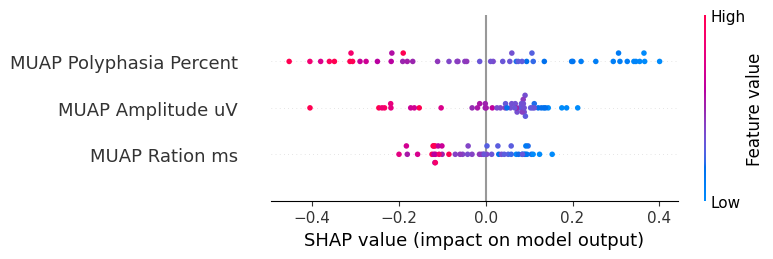

SHAP Summary Plot for: Mild


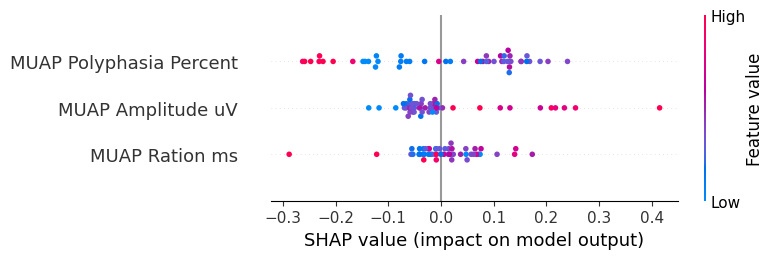

SHAP Summary Plot for: Moderate


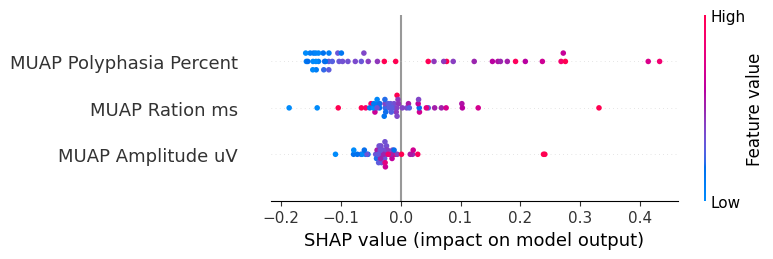

SHAP Summary Plot for: Severe


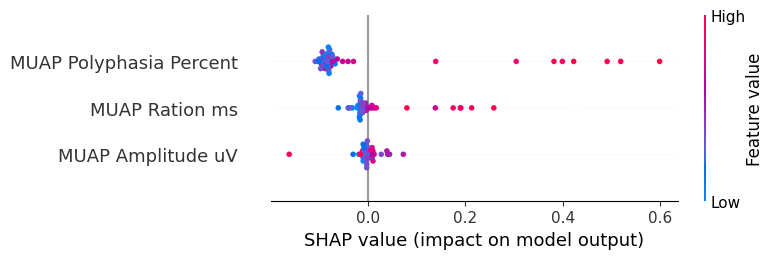

In [14]:
class_names = ["Normal", "Mild", "Moderate", "Severe"]

for i, class_name in enumerate(class_names):
    print("SHAP Summary Plot for:", class_name)

    shap.summary_plot(
        shap_values[:, :, i],
        X_explain,
        feature_names=X_explain.columns
    )

In [15]:
import numpy as np
import pandas as pd

feature_names = X_explain.columns
class_names = ["Normal", "Mild", "Moderate", "Severe"]

for i, class_name in enumerate(class_names):
    print(f"\nFeature Importance for {class_name}:\n")


    importance = np.mean(np.abs(shap_values[:, :, i]), axis=0)

    df_importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    }).sort_values(by="Importance", ascending=False)

    print(df_importance)


Feature Importance for Normal:

                   Feature  Importance
2  MUAP Polyphasia Percent    0.208460
0        MUAP Amplitude uV    0.107274
1           MUAP Ration ms    0.081961

Feature Importance for Mild:

                   Feature  Importance
2  MUAP Polyphasia Percent    0.129451
0        MUAP Amplitude uV    0.072145
1           MUAP Ration ms    0.047882

Feature Importance for Moderate:

                   Feature  Importance
2  MUAP Polyphasia Percent    0.140006
1           MUAP Ration ms    0.047500
0        MUAP Amplitude uV    0.042947

Feature Importance for Severe:

                   Feature  Importance
2  MUAP Polyphasia Percent    0.133188
1           MUAP Ration ms    0.038251
0        MUAP Amplitude uV    0.014491


In [16]:
importance_all = []

for i, class_name in enumerate(class_names):
    importance = np.mean(np.abs(shap_values[:, :, i]), axis=0)

    importance_all.append(importance)

df_all = pd.DataFrame(
    np.array(importance_all).T,
    columns=class_names,
    index=X_explain.columns
)

df_all

,Normal,Mild,Moderate,Severe
MUAP Amplitude uV,0.107274,0.072145,0.042947,0.014491
MUAP Ration ms,0.081961,0.047882,0.047500,0.038251
MUAP Polyphasia Percent,0.208460,0.129451,0.140006,0.133188
